# 使用CNN实现手写数字识别（基于MNIST数据集）；

这个项目使用卷积神经网络（CNN）来识别手写数字。
数据集采用经典的MNIST数据集，包含60000张训练图片和10000张测试图片。

In [4]:
import torch;
import torch.nn as nn;
import torch.optim as optim;
from torch.utils.data import DataLoader;
import torchvision;
import torchvision.transforms as transforms;
import numpy as np;
import matplotlib.pyplot as plt;
import time;


# 设置Matplotlib中文字体支持。
plt.rcParams['font.sans-serif'] = ['SimHei'];
plt.rcParams['axes.unicode_minus'] = False;


# 设置Matplotlib中文字体支持。
plt.rcParams['font.sans-serif'] = ['SimHei'];
plt.rcParams['axes.unicode_minus'] = False;

In [5]:
# 设置训练时的批次大小。
batch_size = 1024*2;

## 数据处理：

In [6]:
# 定义数据预处理的变换操作。
transform = transforms.Compose([
    # 将图片转换为PyTorch张量格式。
    transforms.ToTensor(),
    # 对数据进行标准化处理，均值为0.1307，标准差为0.3081（MNIST数据集的经验值）。
    transforms.Normalize((0.1307,), (0.3081,))
]);

### 划分训练集和测试集；

In [7]:
# 下载并加载MNIST 训练数据集。
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    # 设置为训练集模式。
    train=True,
    # 下载数据集（如果不存在）。
    download=True,
    # 应用前面定义的预处理变换。
    transform=transform
);

# 下载并加载MNIST 测试数据集。
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    # 设置为测试集模式。
    train=False,
    
    download=True,
    
    transform=transform
);

100%|██████████| 9.91M/9.91M [00:00<00:00, 45.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.09MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


In [8]:
# 创建训练数据加载器。
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,  # Kaggle環境可以設置為4。
    pin_memory=True,  # 加速GPU數據傳輸。
    persistent_workers=True  # 保持數據加載進程。
);

# 创建测试数据加载器。
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
);

### 查看数据集的基本信息。

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei


训练集样本数量: 60000
测试集样本数量: 10000
图片尺寸: torch.Size([1, 28, 28])
类别数量: 10


/tmp/ipykernel_55/3431876576.py:23: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
/tmp/ipykernel_55/3431876576.py:23: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of 

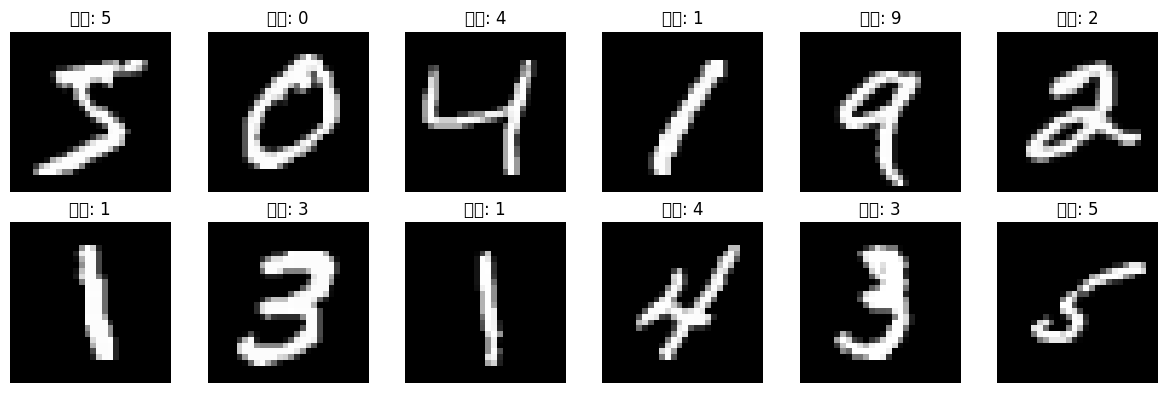

In [9]:
print(f"训练集样本数量: {len(train_dataset)}");
print(f"测试集样本数量: {len(test_dataset)}");
print(f"图片尺寸: {train_dataset[0][0].shape}");
print(f"类别数量: {len(train_dataset.classes)}");

# 创建一个图形窗口，设置大小为12x4。
plt.figure(figsize=(12, 4));
# 循环显示12张图片。
for i in range(12):
    # 创建子图，2行6列，当前是第i+1个。
    plt.subplot(2, 6, i + 1);
    # 获取第i张图片和标签。
    img, label = train_dataset[i];
    # 将张量转换为numpy数组并去掉通道维度，方便显示。
    img = img.squeeze().numpy();
    # 显示图片，使用灰度颜色映射。
    plt.imshow(img, cmap='gray');
    # 设置标题为对应的数字标签。
    plt.title(f'标签: {label}');
    # 不显示坐标轴。
    plt.axis('off');
# 调整子图间距。
plt.tight_layout();
# 显示图形。
plt.show();

## 模型：

In [10]:
# 定义卷积神经网络模型类。
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__();
        # 第一个卷积层：输入1通道（灰度图），输出32通道，卷积核大小3x3。
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1);
        # 第一个批归一化层，对32个通道进行归一化。
        self.bn1 = nn.BatchNorm2d(32);
        # ReLU激活函数，引入非线性。
        self.relu1 = nn.ReLU();
        # 第一个最大池化层，池化核大小2x2，步长2。
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2);
        
        # 第二个卷积层：输入32通道，输出64通道。
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1);
        # 第二个批归一化层。
        self.bn2 = nn.BatchNorm2d(64);
        # ReLU激活函数。
        self.relu2 = nn.ReLU();
        # 第二个最大池化层。
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2);
        
        # 第三个卷积层：输入64通道，输出128通道。
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1);
        # 第三个批归一化层。
        self.bn3 = nn.BatchNorm2d(128);
        # ReLU激活函数。
        self.relu3 = nn.ReLU();
        # 第三个最大池化层。
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2);
        
        # Dropout层，用于防止过拟合，丢弃概率0.5。
        self.dropout = nn.Dropout(0.5);
        # 第一个全连接层：输入128*3*3=1152，输出256。
        self.fc1 = nn.Linear(128 * 3 * 3, 256);
        # 第四个ReLU激活函数。
        self.relu4 = nn.ReLU();
        # 第二个Dropout层。
        self.dropout2 = nn.Dropout(0.5);
        # 第二个全连接层：输入256，输出10（对应0-9十个数字类别）。
        self.fc2 = nn.Linear(256, 10);
    
    # 前向传播函数，定义数据流向。
    def forward(self, x):
        # 第一层卷积+批归一化+激活+池化。
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))));
        # 第二层卷积+批归一化+激活+池化。
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))));
        # 第三层卷积+批归一化+激活+池化。
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))));
        # 将特征图展平为一维向量。
        x = x.view(x.size(0), -1);
        # Dropout正则化。
        x = self.dropout(x);
        # 第一层全连接+激活。
        x = self.relu4(self.fc1(x));
        # Dropout正则化。
        x = self.dropout2(x);
        # 第二层全连接，输出分类结果。
        x = self.fc2(x);
        # 返回输出结果。
        return x;

In [11]:
# 检查是否有可用的GPU。
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');
print(f"使用设备: {device}");

# 创建模型实例。
model = CNN();

# 多GPU支持。
if torch.cuda.device_count() > 1:
    print(f"使用 {torch.cuda.device_count()} 个GPU进行训练！");
    model = nn.DataParallel(model);

# 将模型移动到指定设备（GPU或CPU）。
model = model.to(device);

使用设备: cuda
使用 2 个GPU进行训练！


## 训练：

In [12]:
# 定义损失函数，使用交叉熵损失。
criterion = nn.CrossEntropyLoss();
# 定义优化器，使用Adam优化器，学习率0.001。
optimizer = optim.Adam(model.parameters(), lr=0.001);
# 定义学习率调度器，每10个epoch将学习率乘以0.1。
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1);

# 混合精度训练scaler。
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None;

In [13]:
# 定义训练函数。
def train(model, train_loader, criterion, optimizer, device, scaler=None):
    model.train();
    running_loss = 0.0;
    correct = 0;
    total = 0;
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device);
        
        optimizer.zero_grad();
        
        # 新增：使用自动混合精度
        if scaler is not None:
            with torch.cuda.amp.autocast():
                output = model(data);
                loss = criterion(output, target);
            scaler.scale(loss).backward();
            scaler.step(optimizer);
            scaler.update();
        else:
            output = model(data);
            loss = criterion(output, target);
            loss.backward();
            optimizer.step();
        
        running_loss += loss.item();
        _, predicted = output.max(1);
        total += target.size(0);
        correct += predicted.eq(target).sum().item();
    
    avg_loss = running_loss / len(train_loader);
    accuracy = 100. * correct / total;
    return avg_loss, accuracy;

In [14]:
# 定义测试函数。
def test(model, test_loader, criterion, device):
    # 将模型设置为评估模式。
    model.eval();
    # 初始化累计损失。
    running_loss = 0.0;
    # 初始化正确预测数量。
    correct = 0;
    # 初始化总样本数量。
    total = 0;
    
    # 不计算梯度，节省内存和计算资源。
    with torch.no_grad():
        # 遍历测试数据加载器。
        for data, target in test_loader:
            # 将数据移动到指定设备。
            data, target = data.to(device), target.to(device);
            # 前向传播。
            output = model(data);
            # 计算损失。
            loss = criterion(output, target);
            # 累加损失值。
            running_loss += loss.item();
            # 获取预测结果。
            _, predicted = output.max(1);
            # 累加总样本数。
            total += target.size(0);
            # 累加正确预测数。
            correct += predicted.eq(target).sum().item();
    
    # 计算平均损失。
    avg_loss = running_loss / len(test_loader);
    # 计算准确率。
    accuracy = 100. * correct / total;
    # 返回平均损失和准确率。
    return avg_loss, accuracy;

In [15]:
%%time

# 设置训练轮数。
num_epochs = 50;  # 建議改為50，2000輪太多

# 创建列表用于存储训练历史。
train_losses = [];
train_accuracies = [];
test_losses = [];
test_accuracies = [];

# 新增：最佳模型跟踪
best_accuracy = 0.0;

# 开始训练循环。
for epoch in range(num_epochs):
    epoch_start = time.time();  # 新增：計時
    
    # 修改：傳入scaler參數
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device, scaler);
    test_loss, test_acc = test(model, test_loader, criterion, device);
    
    scheduler.step();
    
    train_losses.append(train_loss);
    train_accuracies.append(train_acc);
    test_losses.append(test_loss);
    test_accuracies.append(test_acc);
    
    epoch_time = time.time() - epoch_start;  # 新增：計算耗時
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}% "
          f"Time: {epoch_time:.2f}s");  # 新增：顯示時間
    
    # 新增：保存最佳模型
    if test_acc > best_accuracy:
        best_accuracy = test_acc;
        # 如果是多GPU，保存model.module的狀態
        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), 'mnist_cnn_best.pth');
        else:
            torch.save(model.state_dict(), 'mnist_cnn_best.pth');
        print(f"  最佳模型已保存 (准确率: {best_accuracy:.2f}%)");

/tmp/ipykernel_55/1193461473.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/50] Train Loss: 0.8236, Train Acc: 73.27% Test Loss: 0.1384, Test Acc: 95.75% Time: 9.99s
  最佳模型已保存 (准确率: 95.75%)
Epoch [2/50] Train Loss: 0.1404, Train Acc: 95.84% Test Loss: 0.0718, Test Acc: 97.75% Time: 6.22s
  最佳模型已保存 (准确率: 97.75%)
Epoch [3/50] Train Loss: 0.0944, Train Acc: 97.21% Test Loss: 0.0445, Test Acc: 98.67% Time: 5.98s
  最佳模型已保存 (准确率: 98.67%)
Epoch [4/50] Train Loss: 0.0764, Train Acc: 97.65% Test Loss: 0.0366, Test Acc: 98.83% Time: 6.17s
  最佳模型已保存 (准确率: 98.83%)
Epoch [5/50] Train Loss: 0.0650, Train Acc: 98.07% Test Loss: 0.0313, Test Acc: 98.95% Time: 6.25s
  最佳模型已保存 (准确率: 98.95%)
Epoch [6/50] Train Loss: 0.0566, Train Acc: 98.29% Test Loss: 0.0419, Test Acc: 98.66% Time: 6.15s
Epoch [7/50] Train Loss: 0.0515, Train Acc: 98.44% Test Loss: 0.0277, Test Acc: 99.10% Time: 6.09s
  最佳模型已保存 (准确率: 99.10%)
Epoch [8/50] Train Loss: 0.0454, Train Acc: 98.69% Test Loss: 0.0341, Test Acc: 98.92% Time: 6.01s
Epoch [9/50] Train Loss: 0.0441, Train Acc: 98.66% Test Loss: 0.

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_55/3660801241.py:39: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
/t

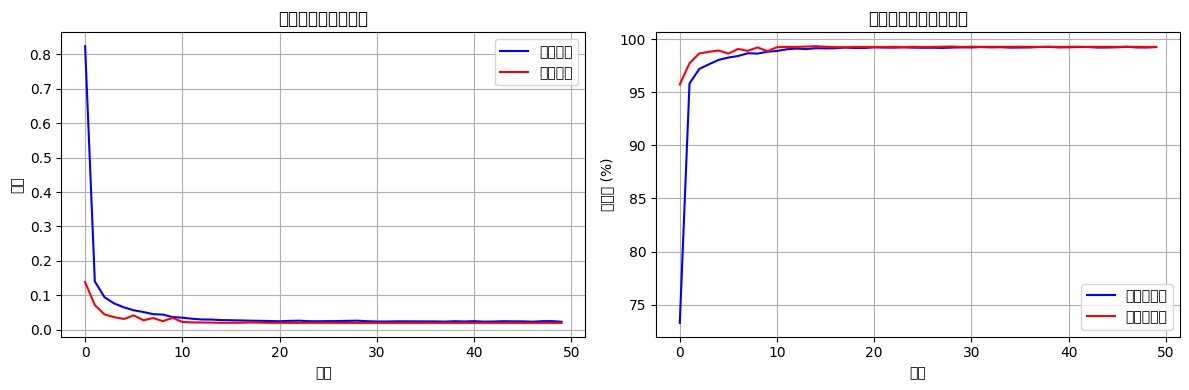

In [16]:
# 绘制训练过程中的损失变化曲线。
plt.figure(figsize=(12, 4));

# 绘制损失曲线。
plt.subplot(1, 2, 1);
# 绘制训练损失。
plt.plot(train_losses, label='训练损失', color='blue');
# 绘制测试损失。
plt.plot(test_losses, label='测试损失', color='red');
# 设置x轴标签。
plt.xlabel('轮次');
# 设置y轴标签。
plt.ylabel('损失');
# 设置标题。
plt.title('训练和测试损失变化');
# 显示图例。
plt.legend();
# 显示网格。
plt.grid(True);

# 绘制准确率曲线。
plt.subplot(1, 2, 2);
# 绘制训练准确率。
plt.plot(train_accuracies, label='训练准确率', color='blue');
# 绘制测试准确率。
plt.plot(test_accuracies, label='测试准确率', color='red');
# 设置x轴标签。
plt.xlabel('轮次');
# 设置y轴标签。
plt.ylabel('准确率 (%)');
# 设置标题。
plt.title('训练和测试准确率变化');
# 显示图例。
plt.legend();
# 显示网格。
plt.grid(True);

# 调整子图间距。
plt.tight_layout();
# 显示图形。
plt.show();

In [17]:
# 保存训练好的模型（修改：支持多GPU）
if isinstance(model, nn.DataParallel):
    torch.save(model.module.state_dict(), 'mnist_cnn_model.pth');
else:
    torch.save(model.state_dict(), 'mnist_cnn_model.pth');

print("模型已保存到 mnist_cnn_model.pth");

模型已保存到 mnist_cnn_model.pth


In [18]:
# 加载保存的模型（如果需要）。
# model = CNN();
# model.load_state_dict(torch.load('mnist_cnn_model.pth'));
# model = model.to(device);
# model.eval();

In [19]:
# 定义函数用于可视化预测结果。
def visualize_predictions(model, test_loader, device, num_images=16):
    # 将模型设置为评估模式。
    model.eval();
    # 获取一批测试数据。
    data_iter = iter(test_loader);
    images, labels = next(data_iter);
    
    # 将数据移动到指定设备。
    images = images.to(device);
    
    # 不计算梯度。
    with torch.no_grad():
        # 前向传播获取预测结果。
        outputs = model(images);
        # 获取预测类别。
        _, predicted = outputs.max(1);
    
    # 将数据移回CPU以便可视化。
    images = images.cpu();
    predicted = predicted.cpu();
    
    # 创建图形窗口。
    plt.figure(figsize=(12, 12));
    
    # 循环显示图片。
    for i in range(num_images):
        # 创建子图，4行4列。
        plt.subplot(4, 4, i + 1);
        # 获取第i张图片。
        img = images[i].squeeze().numpy();
        # 显示图片。
        plt.imshow(img, cmap='gray');
        
        # 获取真实标签和预测标签。
        true_label = labels[i].item();
        pred_label = predicted[i].item();
        
        # 如果预测正确显示绿色，错误显示红色。
        color = 'green' if true_label == pred_label else 'red';
        # 设置标题。
        plt.title(f'真实: {true_label}, 预测: {pred_label}', color=color);
        # 不显示坐标轴。
        plt.axis('off');
    
    # 调整子图间距。
    plt.tight_layout();
    # 显示图形。
    plt.show();
    
    # 计算这批数据的准确率。
    accuracy = (predicted[:num_images] == labels[:num_images]).sum().item() / num_images * 100;
    # 打印准确率。
    print(f"这批样本的准确率: {accuracy:.2f}%");

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_55/2730207397.py:47: UserWarnin

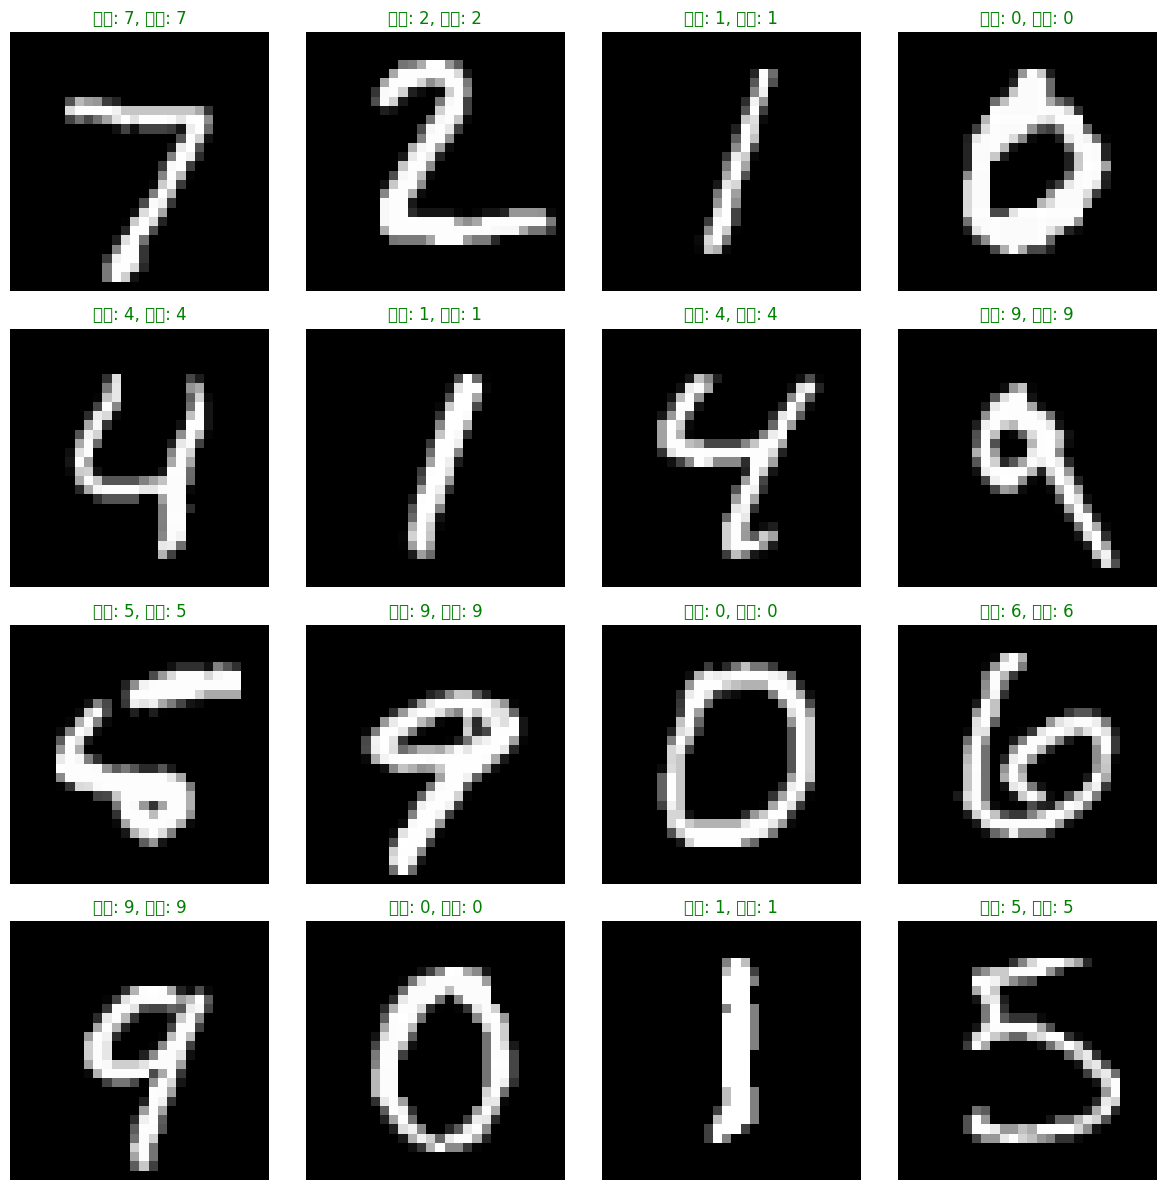

这批样本的准确率: 100.00%


In [20]:
# 调用函数可视化预测结果。
visualize_predictions(model, test_loader, device);

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

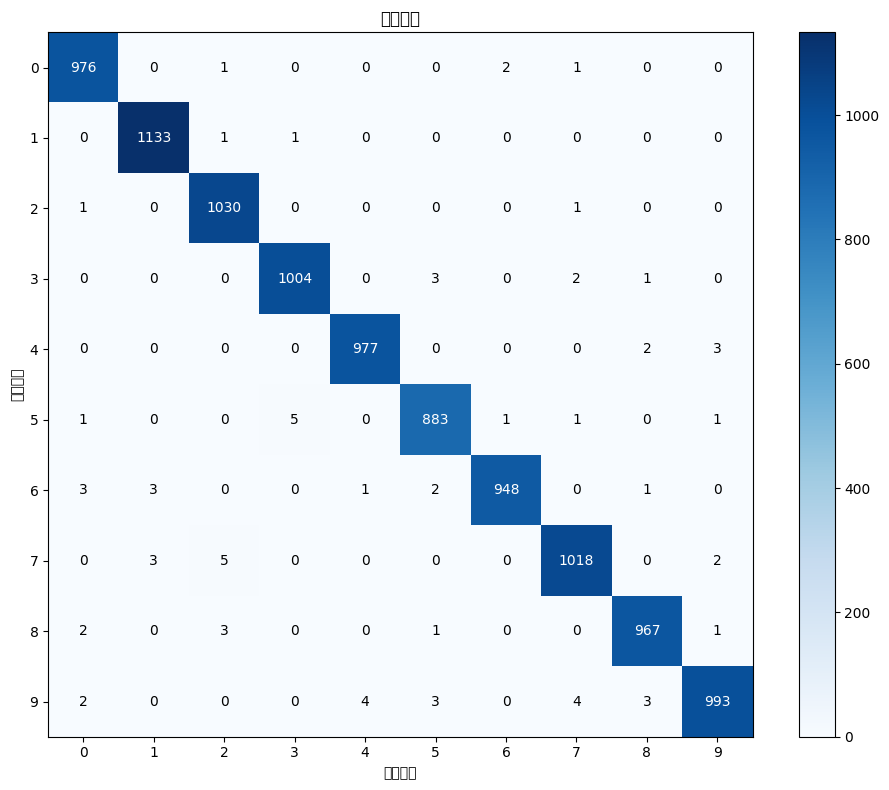

In [21]:
# 计算整个测试集的混淆矩阵。
from sklearn.metrics import confusion_matrix, classification_report;

# 收集所有预测结果和真实标签。
all_preds = [];
all_labels = [];

# 将模型设置为评估模式。
model.eval();

# 不计算梯度。
with torch.no_grad():
    # 遍历测试集。
    for images, labels in test_loader:
        # 将数据移动到设备。
        images = images.to(device);
        # 前向传播。
        outputs = model(images);
        # 获取预测结果。
        _, predicted = outputs.max(1);
        # 将预测结果移回CPU并添加到列表。
        all_preds.extend(predicted.cpu().numpy());
        # 添加真实标签。
        all_labels.extend(labels.numpy());

# 计算混淆矩阵。
cm = confusion_matrix(all_labels, all_preds);

# 绘制混淆矩阵热力图。
plt.figure(figsize=(10, 8));
# 使用imshow显示矩阵。
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues);
# 设置标题。
plt.title('混淆矩阵');
# 添加颜色条。
plt.colorbar();

# 设置刻度。
tick_marks = np.arange(10);
plt.xticks(tick_marks, range(10));
plt.yticks(tick_marks, range(10));

# 在格子里显示数值。
thresh = cm.max() / 2.0;
for i in range(10):
    for j in range(10):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black");

# 设置坐标轴标签。
plt.ylabel('真实标签');
plt.xlabel('预测标签');
# 调整布局。
plt.tight_layout();
# 显示图形。
plt.show();

In [22]:
# 打印详细的分类报告。
print("\n分类报告:");
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]));


分类报告:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [23]:
# 查看每个数字的识别准确率。
# 初始化每个类别的正确数和总数。
class_correct = list(0. for i in range(10));
class_total = list(0. for i in range(10));

# 将模型设置为评估模式。
model.eval();

# 不计算梯度。
with torch.no_grad():
    # 遍历测试集。
    for images, labels in test_loader:
        # 将数据移动到设备。
        images, labels = images.to(device), labels.to(device);
        # 前向传播。
        outputs = model(images);
        # 获取预测结果。
        _, predicted = outputs.max(1);
        # 获取正确预测的掩码。
        c = (predicted == labels).squeeze();
        # 遍历批次中的每个样本。
        for i in range(len(labels)):
            # 获取当前样本的标签。
            label = labels[i];
            # 累加正确数。
            class_correct[label] += c[i].item();
            # 累加总数。
            class_total[label] += 1;

# 打印每个数字的准确率。
print("\n每个数字的识别准确率:");
for i in range(10):
    # 计算并打印准确率。
    accuracy = 100 * class_correct[i] / class_total[i];
    print(f"数字 {i}: {accuracy:.2f}% ({int(class_correct[i])}/{int(class_total[i])})");


每个数字的识别准确率:
数字 0: 99.59% (976/980)
数字 1: 99.82% (1133/1135)
数字 2: 99.81% (1030/1032)
数字 3: 99.41% (1004/1010)
数字 4: 99.49% (977/982)
数字 5: 98.99% (883/892)
数字 6: 98.96% (948/958)
数字 7: 99.03% (1018/1028)
数字 8: 99.28% (967/974)
数字 9: 98.41% (993/1009)


In [26]:
# 單張圖片預測測試
def predict_single_image(model, image, device):
    """預測單張圖片"""
    model.eval()
    with torch.no_grad():
        # 添加batch維度並移動到設備
        image = image.unsqueeze(0).to(device)
        output = model(image)
        # 獲取預測結果和置信度
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

# 測試幾張圖片
print("=" * 50)
print("單張圖片預測測試")
print("=" * 50)

# 從測試集隨機選擇5張圖片
import random
test_indices = random.sample(range(len(test_dataset)), 5)

for idx in test_indices:
    img, true_label = test_dataset[idx]
    pred_label, confidence, probs = predict_single_image(model, img, device)
    
    print(f"\n圖片 {idx}:")
    print(f"  真實標籤: {true_label}")
    print(f"  預測標籤: {pred_label}")
    print(f"  置信度: {confidence:.4f}")
    print(f"  預測正確: {'✓' if pred_label == true_label else '✗'}")
    
    # 顯示前3個最可能的類別
    top3_indices = np.argsort(probs)[-3:][::-1]
    print(f"  Top-3 預測:")
    for i, class_idx in enumerate(top3_indices):
        print(f"    {i+1}. 數字 {class_idx}: {probs[class_idx]:.4f}")

單張圖片預測測試

圖片 3656:
  真實標籤: 7
  預測標籤: 7
  置信度: 1.0000
  預測正確: ✓
  Top-3 預測:
    1. 數字 7: 1.0000
    2. 數字 2: 0.0000
    3. 數字 9: 0.0000

圖片 3633:
  真實標籤: 8
  預測標籤: 8
  置信度: 1.0000
  預測正確: ✓
  Top-3 預測:
    1. 數字 8: 1.0000
    2. 數字 2: 0.0000
    3. 數字 3: 0.0000

圖片 5455:
  真實標籤: 2
  預測標籤: 2
  置信度: 1.0000
  預測正確: ✓
  Top-3 預測:
    1. 數字 2: 1.0000
    2. 數字 7: 0.0000
    3. 數字 8: 0.0000

圖片 6350:
  真實標籤: 6
  預測標籤: 6
  置信度: 1.0000
  預測正確: ✓
  Top-3 預測:
    1. 數字 6: 1.0000
    2. 數字 0: 0.0000
    3. 數字 8: 0.0000

圖片 4773:
  真實標籤: 7
  預測標籤: 7
  置信度: 1.0000
  預測正確: ✓
  Top-3 預測:
    1. 數字 7: 1.0000
    2. 數字 1: 0.0000
    3. 數字 3: 0.0000
